In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import os
import matplotlib.pyplot as plt
from collections import OrderedDict
from PIL import Image
import random
import sys
import numpy as np
from sklearn.metrics import confusion_matrix


# ======================= Import dataset utilities ========================
os.chdir("/content/drive/MyDrive/Colab Notebooks/NVDIA_Project/Image-level-micro-gesture-classification")
from dataset import get_train_loader, get_train_dataset

# ======================= Import model utilities ========================
from models.resnet18_model import build_resnet18

In [ ]:
# Connection check to GPU and check if it's available
print(torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
!nvidia-smi

True
Thu Mar 19 12:30:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             15W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+

In [ ]:
# ------------------ Train and validation data loaders-------------------
# Note: Update the train_dir path to your dataset location
#       If you want to connect to your Google Drive, you can use the first path, but it is slower than the second path which is directly in the Colab environment. 
#       You can copy your dataset to the Colab environment for faster access.
#       In our group, we uploaded the dataset as a ZIP file to the Colab environment, then unzipped it and used the second path for training.


# train_dir = "/content/drive/MyDrive/Colab Notebooks/NVDIA_Project/Image-level-micro-gesture-classification/data/train"
train_dir = "/content/train"
batch_size = 64
trainloader, valloader = get_train_loader(train_dir=train_dir, batch_size=batch_size, val_split=0.25)

In [ ]:
# Step 3: Model Selection - Test loading a pre-trained model
model = build_resnet18()
model.to(device)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [ ]:
print(len(trainloader))

710


In [ ]:
num_epochs = 10
train_losses, val_losses, train_acc_list, val_acc_list = [], [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for idx, (inputs, labels) in enumerate(trainloader):

        if ((idx+1) % 100 == 0) or ((idx+1) == len(trainloader)):
            print(f"Batch {idx+1}/{len(trainloader)}")

        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(trainloader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for idx, (inputs, labels) in enumerate(valloader):

            if ((idx+1) % 100 == 0) or (idx+1) == len(valloader):
                print(f"Batch {idx+1}/{len(valloader)}")

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(valloader.dataset)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_acc_list.append(val_acc)

    scheduler.step(val_loss)
    print(f'\n----- Epoch [{epoch+1}/{num_epochs}] -----\n Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%')

Batch 100/710
Batch 200/710
Batch 300/710
Batch 400/710
Batch 500/710
Batch 600/710
Batch 700/710
Batch 710/710
Batch 100/237
Batch 200/237
Batch 237/237

----- Epoch [1/10] -----
 Train Loss: 2.9322 | Train Acc: 26.81% | Val Acc: 27.65%


/tmp/ipykernel_8292/4158687132.py:52: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


Batch 100/710
Batch 200/710
Batch 300/710
Batch 400/710
Batch 500/710
Batch 600/710
Batch 700/710
Batch 710/710
Batch 100/237
Batch 200/237
Batch 237/237

----- Epoch [2/10] -----
 Train Loss: 2.4531 | Train Acc: 28.34% | Val Acc: 28.86%
Batch 100/710
Batch 200/710
Batch 300/710
Batch 400/710
Batch 500/710
Batch 600/710
Batch 700/710
Batch 710/710
Batch 100/237
Batch 200/237
Batch 237/237

----- Epoch [3/10] -----
 Train Loss: 2.3272 | Train Acc: 31.05% | Val Acc: 31.71%
Batch 100/710
Batch 200/710
Batch 300/710
Batch 400/710
Batch 500/710
Batch 600/710
Batch 700/710
Batch 710/710
Batch 100/237
Batch 200/237
Batch 237/237

----- Epoch [4/10] -----
 Train Loss: 2.1243 | Train Acc: 35.10% | Val Acc: 32.26%
Batch 100/710
Batch 200/710
Batch 300/710
Batch 400/710
Batch 500/710
Batch 600/710
Batch 700/710
Batch 710/710
Batch 100/237
Batch 200/237
Batch 237/237

----- Epoch [5/10] -----
 Train Loss: 1.9411 | Train Acc: 39.33% | Val Acc: 29.90%
Batch 100/710
Batch 200/710
Batch 300/710
Batch 

In [ ]:
save_path = "outputs/checkpoints/resnet18_micro_gesture.pth"

torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: outputs/checkpoints/resnet18_micro_gesture.pth


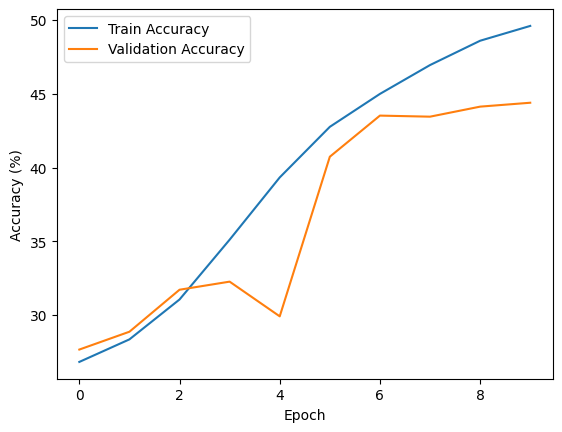

In [ ]:
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

In [12]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in valloader:

        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        _, predicted = outputs.max(1)

        # store predictions
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

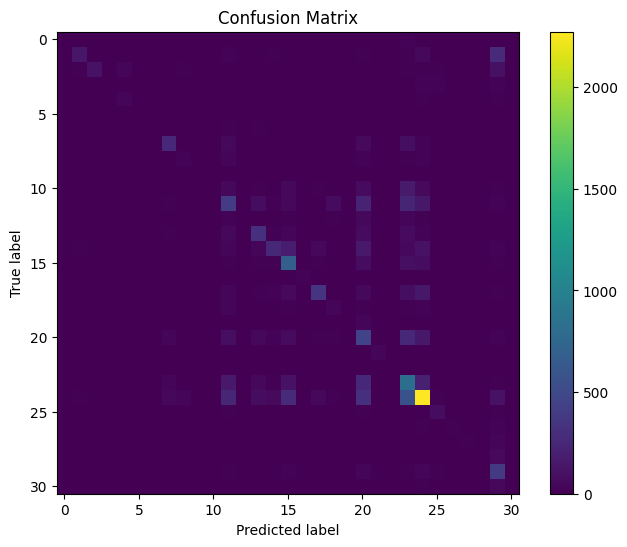

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
plt.show()